<a href="https://colab.research.google.com/github/meirBal/meir/blob/main/207116872_Ex2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cars 2025: Environment Setup and Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import kagglehub
import os
import matplotlib.patches as mpatches # For custom legend
import warnings
import re

from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report, roc_curve, auc, matthews_corrcoef, precision_recall_curve, fbeta_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from scipy.stats import skew, kurtosis

# Set display style for plots
sns.set_theme(style="whitegrid")

 # Ignore warnings from sklearn or pandas
warnings.filterwarnings('ignore')

# Define the K-Fold cross-validation strategy globally as it's a critical requirement
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("K-Fold cross-validation strategy initialized with k=5, shuffle=True, random_state=42.")
print("This choice is based on the dataset size (~1200 rows), ensuring approximately 240 rows per validation fold,")
print("which balances the bias-variance trade-off and computational cost.")

K-Fold cross-validation strategy initialized with k=5, shuffle=True, random_state=42.
This choice is based on the dataset size (~1200 rows), ensuring approximately 240 rows per validation fold,
which balances the bias-variance trade-off and computational cost.


## Part 1: Dataset Selection and Overview

This section introduces the dataset used for the analysis, detailing its source, purpose, and key characteristics. It ensures a foundational understanding of the data before proceeding with cleaning and modeling.

### 1.1 Dataset Overview

**Source:** The data was downloaded from the Kaggle platform.
**Dataset Name:** 'Cars Datasets 2025' (Kaggle ID: `abdulmalik1518/cars-datasets-2025`).
**Purpose:** Intended to facilitate project building and market research in the automotive industry, covering aspects such as acceleration performance, speed, horsepower, market prices (in USD), and propulsion types (petrol, hybrid, electric, diesel).
**Requirements Met:** The dataset meets the assignment's requirements – it is tabular, contains over 1000 rows, more than 10 columns (companies, models, price, fuel type, seats, etc.), and includes both numerical and categorical variables.

### 1.1 Dataset Overview for Data Analysts

This section provides essential details about the 'Cars Datasets 2025' dataset, crucial for any data analyst working with this file.

**1. Dataset Name:** Cars Datasets 2025

**2. Source:** Kaggle Platform
   *   **Kaggle Dataset ID:** `abdulmalik1518/cars-datasets-2025`
   *   **Direct URL:** [https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025](https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025)
   *   **Uploader:** abdulmalik1518
   *   **License:** Apache-2.0

**3. Date Accessed:** This dataset was downloaded and integrated into the notebook for analysis on [Insert Current Date/Approximate Access Date if known, e.g., April 2026 based on Kaggle logs].

**4. Purpose of Collection:** This dataset was collected to facilitate project building and market research within the automotive industry. It provides detailed information on various car models for the year 2025, enabling analysis of market trends, performance benchmarks, and competitive landscapes.

**5. Key Data Characteristics:**
   *   **Structure:** Tabular data.
   *   **Size:** Contains an initial 1218 entries (rows) and 11 columns, with cleaned data resulting in 1213 entries and additional derived columns.
   *   **Variables:** The dataset includes a mix of numerical and categorical variables:
        *   **Numerical (Cleaned):** `HorsePower_cleaned`, `Total Speed_cleaned`, `Cars Prices_cleaned`, `Torque_cleaned`, `CC_Capacity_cleaned`, `Battery_Capacity_cleaned`, `Performance_cleaned`.
        *   **Categorical:** `Company Names`, `Cars Names`, `Fuel Types`, `Seats`, `Engine_Category`.
   *   **Content Focus:** Covers aspects such as acceleration performance, top speed, horsepower, market prices (in USD), and propulsion types (petrol, hybrid, electric, diesel).

**6. Data Granularity:** Each row typically represents a specific car model with its detailed specifications.

> KAGGLE

In [ ]:
# Install the Kaggle library
!pip install kaggle

In [ ]:
# Upload the Kaggle API key to your notebook
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
# Place the API key where the Kaggle library can recognize it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download abdulmalik1518/cars-datasets-2025
!unzip cars-datasets-2025.zip

Dataset URL: https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025
License(s): apache-2.0
100% 25.4k/25.4k [00:00<00:00, 40.7MB/s]

Archive:  cars-datasets-2025.zip
  inflating: Cars Datasets 2025.csv  


In [ ]:
data = pd.read_csv('./Cars Datasets 2025.csv', encoding='latin1')
df = data

## Part 2: Initial Data Inspection and Cleansing

Our first step is to gain a foundational understanding of the dataset's structure and contents. This involves inspecting the data types, identifying missing values, and detecting any duplicate entries. Addressing these basic issues early ensures that our subsequent analysis is based on a robust and reliable dataset. We want to quickly see the general health of our data.

In [ ]:
# Display basic information about the DataFrame, including data types and non-null counts.
df.info()

# Check for and remove duplicate rows to ensure each entry is unique.
print(f"\nNumber of duplicate rows in df before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows in df after removal: {df.duplicated().sum()}")

# Display a summary of missing values for all columns, showing count and percentage.
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing_data, 'Percent (%)': missing_percent})
print("\n--- Missing Values Initial Check ---")
display(missing_df[missing_df['Missing'] > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB

Number of duplicate rows in df before removal: 4
Number of duplicate rows in df after removal: 0

--- Missing Values Initial Check ---

,Missing,Percent (%)
CC/Battery Capacity,3,0.247117
Performance(0 - 100 )KM/H,6,0.494234
Torque,1,0.082372


### 2.1 Cardinality Check and Unique Value Analysis

Beyond duplicates, understanding the cardinality of each column—the number of unique values it contains—is crucial. Low cardinality columns (especially those with just one unique value) might be constant and thus uninformative for analysis, or indicate potential issues if they should have more variance. High cardinality columns (many unique values) can point to identifier-like features or require specific handling for categorical analysis.

In [ ]:
try:
    # Attempt to use existing df if it's already defined
    df.head()
except NameError:
    # If df is not defined, first check if the file exists
    file_path = './Cars Datasets 2025.csv'
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}. Attempting to re-download and unzip.")
        # Re-run Kaggle download and unzip commands. This assumes Kaggle API is already configured.
        # Adding -q for quiet output and -o for overwrite (if zip exists) for unzip.
        !kaggle datasets download abdulmalik1518/cars-datasets-2025 -q
        !unzip -o cars-datasets-2025.zip -d .
        # Remove the zip file after extraction to keep the directory clean
        if os.path.exists('cars-datasets-2025.zip'):
            os.remove('cars-datasets-2025.zip')

    # Now try to load the data from the (now hopefully present) file
    data = pd.read_csv(file_path, encoding='latin1')
    df = data

# Check cardinality for all columns in the current DataFrame.
print("--- Cardinality of each column in df ---")
cardinality_df = pd.DataFrame({'Column': df.columns, 'Unique Values': df.nunique().values})
display(cardinality_df.sort_values(by='Unique Values', ascending=False))

# Identify columns with very low cardinality (e.g., only one unique value).
single_value_cols = cardinality_df[cardinality_df['Unique Values'] == 1]['Column'].tolist()

if single_value_cols:
    print(f"\n--- Columns with only one unique value (potentially uninformative): {single_value_cols} ---\n")
    for col in single_value_cols:
        print(f"Column '{col}': Unique value is '{df[col].iloc[0]}'")
else:
    print("\nNo columns found with only one unique value.")

--- Cardinality of each column in df ---


,Column,Unique Values
1,Cars Names,1201
7,Cars Prices,535
4,HorsePower,456
2,Engines,356
3,CC/Battery Capacity,311
10,Torque,263
6,Performance(0 - 100 )KM/H,180
5,Total Speed,114
0,Company Names,37
8,Fuel Types,23



No columns found with only one unique value.


### 2.2 Handling Specific Missing Values in 'Torque'

Upon initial inspection, we observed that the 'Torque' column contains a few missing values. Specifically, one entry for a Mazda concept car has a missing 'Torque' value, which makes sense as it's a concept and may not have finalized specifications. Given the small number of missing values and the nature of this particular entry, we've decided to remove this row. This approach ensures data integrity without significantly impacting the overall dataset size.

In [ ]:
# Removing rows with NaN values in 'Torque' column as it's a critical performance metric and imputation might not be accurate for a concept car.
df = df.dropna(subset=['Torque']).copy()

## Part 3: Data Cleaning, Transformation, and Feature Engineering

In this section, we focus on transforming raw data into a clean, usable format and creating new features that can enhance our analysis. Many columns currently contain text alongside numerical values or are in formats unsuitable for quantitative analysis. Our goal is to extract clean numerical data, standardize units, and derive meaningful new categorical and descriptive features. This will enable us to perform accurate statistical analysis and build insightful visualizations.



### 3.1 Initial Data Cleaning and Feature Extraction

This step involves cleaning various columns by extracting numerical components, removing extraneous text (e.g., '$', 'cc', 'hp', commas), and converting them to appropriate numerical data types (integers or floats). Specifically, we process `HorsePower`, `Total Speed`, `Cars Prices`, `Torque`, and `Performance(0 - 100 )KM/H`. We also separate `CC/Battery Capacity` into `CC_Capacity_cleaned` and `Battery_Capacity_cleaned` to handle combustion engine displacement and electric battery capacity distinctly. Additionally, we impute missing `CC_Capacity_cleaned` values using information from the `Engines` column where possible, and create a descriptive `Engine_Battery_Description`.

In [ ]:
# Cleaning 'HorsePower': Extract numerical part and convert to integer.
df.loc[:, 'HorsePower_cleaned'] = pd.to_numeric(df['HorsePower'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('Int64')

# Cleaning 'Total Speed': Extract numerical part and convert to integer.
df.loc[:, 'Total Speed_cleaned'] = pd.to_numeric(df['Total Speed'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('Int64')

# Cleaning 'Cars Prices': Remove '$', commas, extract first number, and convert to integer.
df.loc[:, 'Cars Prices_cleaned'] = pd.to_numeric(
    df['Cars Prices'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.extract(r'(\d+)', expand=False),
    errors='coerce').astype('Int64')

# Cleaning 'Torque': Extract numerical part and convert to integer.
df.loc[:, 'Torque_cleaned'] = pd.to_numeric(df['Torque'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('Int64')

# Cleaning 'CC/Battery Capacity': This column contains mixed information (CC for internal combustion, kWh for electric).
# We will extract both into separate cleaned columns.

# 1. Extract CC (cubic capacity) values.
df.loc[:, 'CC_Capacity_cleaned'] = pd.to_numeric(
    df['CC/Battery Capacity'].str.replace(',', '', regex=False).str.extract(r'(\d+)\s*cc', expand=False),
    errors='coerce')

# 2. Extract Battery Capacity (kWh) values.
df.loc[:, 'Battery_Capacity_cleaned'] = pd.to_numeric(
    df['CC/Battery Capacity'].str.replace(',', '', regex=False).str.extract(r'(\d+(?:\.\d+)?)\s*(?:kwh|kWh|Battery\s*\((\d+)\s*kWh\))', expand=False).iloc[:, 0],
    errors='coerce')

# 3. Fill missing CC_Capacity_cleaned values using 'Engines' column (e.g., '2.5L' -> '2500 cc').
liters_from_engines = df['Engines'].str.extract(r'(\d+\.?\d*)\s*L', expand=False)
liters_from_engines = pd.to_numeric(liters_from_engines, errors='coerce')
df.loc[df['CC_Capacity_cleaned'].isnull(), 'CC_Capacity_cleaned'] = \
    df.loc[df['CC_Capacity_cleaned'].isnull()].apply(lambda row: liters_from_engines[row.name] * 1000 if pd.notna(liters_from_engines[row.name]) else np.nan, axis=1)

# Create a new descriptive column combining engine volume and battery capacity for easier understanding.
df['Engine_Battery_Description'] = df['CC/Battery Capacity'].copy() # Initialize with original value as fallback

# Identify vehicle types based on 'Fuel Types' column and cleaned values.
is_electric = df['Fuel Types'] == 'Electric'
is_hybrid = df['Fuel Types'].str.contains('Hybrid', na=False) # includes 'Hybrid (Gas + Electric)', 'Plug-in Hybrid'
is_combustion_only = ~is_electric & ~is_hybrid

# Update descriptions where we have clean data.
# Electric vehicles (battery only) - now with '0 cc' for engine volume.
mask_electric_and_battery_ok = is_electric & df['Battery_Capacity_cleaned'].notna()
df.loc[mask_electric_and_battery_ok, 'Engine_Battery_Description'] = \
    df.loc[mask_electric_and_battery_ok, 'Battery_Capacity_cleaned'].apply(lambda x: f"0 cc + {x:.0f} kWh" if x == int(x) else f"0 cc + {x} kWh")

# Hybrid vehicles (both engine volume and battery).
mask_hybrid_and_cc_battery_ok = is_hybrid & df['CC_Capacity_cleaned'].notna() & df['Battery_Capacity_cleaned'].notna()
df.loc[mask_hybrid_and_cc_battery_ok, 'Engine_Battery_Description'] = \
    df.loc[mask_hybrid_and_cc_battery_ok].apply(
        lambda row: f"{row['CC_Capacity_cleaned']:.0f} cc + {row['Battery_Capacity_cleaned']:.0f} kWh" if row['CC_Capacity_cleaned'] == int(row['CC_Capacity_cleaned']) and row['Battery_Capacity_cleaned'] == int(row['Battery_Capacity_cleaned']) else f"{row['CC_Capacity_cleaned']} cc + {row['Battery_Capacity_cleaned']} kWh",
        axis=1
    )

# Internal combustion vehicles (engine volume only).
mask_combustion_and_cc_ok = is_combustion_only & df['CC_Capacity_cleaned'].notna()
df.loc[mask_combustion_and_cc_ok, 'Engine_Battery_Description'] = \
    df.loc[mask_combustion_and_cc_ok, 'CC_Capacity_cleaned'].apply(lambda x: f"{x:.0f} cc" if x == int(x) else f"{x} cc")

### 3.2 Handling Missing Values in 'Performance (0-100 KM/H)'

The 'Performance (0-100 KM/H)' column, after initial cleaning, still has a few missing values. Since performance is a crucial metric, we want to impute these missing values rather than dropping the rows. Instead of using a global median, which could be misleading, we will use a **group-based median imputation**. Specifically, we will impute missing `Performance_cleaned` values with the median `Performance_cleaned` for each `Engine_Category`. This approach ensures that the imputed values are more representative of similar car types, enhancing the accuracy of our data and making the imputation more robust. The median is chosen over the mean as it is less sensitive to outliers.

In [ ]:
# Function to simplify engine names based on common patterns.
def simplify_engine_name(engine):
    if pd.isna(engine): # Handle potential NaN values.
        return 'Other'
    engine = str(engine).upper()

    # Prioritize electric motors.
    if 'ELECTRIC MOTOR' in engine or 'ELECTRIC' in engine:
        return 'ELECTRIC MOTOR'

    # V-engines (e.g., V8, V6).
    v_match = re.search(r'V\d+', engine)
    if v_match:
        return v_match.group(0)

    # Inline engines (e.g., I4, I6).
    inline_match = re.search(r'INLINE-\d+|I\d+', engine)
    if inline_match:
        return inline_match.group(0).replace('INLINE-', 'I')

    # Hybrid types.
    if 'HYBRID' in engine:
        return 'HYBRID'

    # Fuel types for simpler categorization.
    if 'PETROL' in engine:
        return 'PETROL'
    if 'DIESEL' in engine:
        return 'DIESEL'

    # Engine displacement (e.g., 2.5L).
    liter_match = re.search(r'(\d+\.?\d*)\s*L', engine)
    if liter_match:
        return f'{float(liter_match.group(1)):g}L'

    # If no specific category is found, return 'Other' or a more general term.
    if len(engine.split()) == 1 and not any(char.isdigit() for char in engine):
        return engine

    return 'Other'

# Apply the simplification function to create a new 'Simplified_Engines' column on df.
df['Simplified_Engines'] = df['Engines'].apply(simplify_engine_name)

# Identify the top 10 most frequent simplified engine types.
top_10_simplified_engines = df['Simplified_Engines'].value_counts().nlargest(10).index.tolist()

# Create 'Engine_Category' grouping the top 10 and 'Other' for less frequent types.
df['Engine_Category'] = df['Simplified_Engines'].apply(lambda x: x if x in top_10_simplified_engines else 'Other')

### 3.3 Creating Simplified Engine Categories for Analysis

The 'Engines' column contains a wide variety of detailed engine descriptions, which can be difficult to analyze directly. To simplify our analysis and identify broader trends, we will create a new categorical feature called `Engine_Category`. This involves standardizing engine types (e.g., 'V8', 'I4', 'Electric Motor', 'Hybrid') and grouping less common types into an 'Other' category. This simplification will allow us to visualize and compare car performance and characteristics across major engine classifications.

In [ ]:
# Cleaning 'Performance(0 - 100 )KM/H': Extract numerical part, remove 'sec', and convert to float.
df.loc[:, 'Performance_cleaned'] = pd.to_numeric(
    df['Performance(0 - 100 )KM/H'].str.replace(' sec', '', regex=False).str.extract(r'(\d+\.?\d*)', expand=False),
    errors='coerce')

# Perform group-based median imputation using 'Engine_Category'
# Calculate median performance for each engine category.
median_performance_by_engine = df.groupby('Engine_Category')['Performance_cleaned'].median()

# Fill missing values in the cleaned column using the corresponding engine category's median.
df.loc[:, 'Performance_cleaned'] = df.apply(
    lambda row: median_performance_by_engine[row['Engine_Category']] if pd.isna(row['Performance_cleaned']) else row['Performance_cleaned'],
    axis=1)

print("--- Performance_cleaned after group-based median imputation ---")
print(df['Performance_cleaned'].isnull().sum()) # Should be 0 missing values

--- Performance_cleaned after group-based median imputation ---
0


## Part 4: Addressing Specific Data Anomalies

During the cleaning process, we identified a few specific data anomalies that require careful attention to ensure the accuracy of our analysis. These include electric vehicles appearing with extremely low horsepower and a unique case where cubic capacity (cc) was mistakenly listed in the 'HorsePower' column. Correcting these anomalies is crucial for precise insights into car performance and market value.

### 4.1 Anomaly 1: Correcting Horsepower for Electric Vehicles

We noticed some electric vehicles initially showing '1.0' horsepower, which is an obvious data entry error given their actual performance. Electric vehicles generate torque and power differently than combustion engines, and a '1.0' HP value is highly misleading. We will re-extract their horsepower from the original 'HorsePower' column using a more robust method, ensuring their performance metrics are accurately reflected.

In [ ]:
# Identify electric vehicles with 'HorsePower_cleaned' appearing as 1.0.
electric_hp_anomaly_indices = df[(df['Fuel Types'] == 'Electric') & (df['HorsePower_cleaned'] == 1.0)].index

# If anomalies are found, re-extract and clean the 'HorsePower' value from the original column.
if not electric_hp_anomaly_indices.empty:
    # More comprehensive cleaning: Remove 'Up to', 'hp', and commas before converting to a number.
    cleaned_values = df.loc[electric_hp_anomaly_indices, 'HorsePower'].str.replace('Up to ', '', regex=False) \
                                                                       .str.replace(' hp', '', regex=False) \
                                                                       .str.replace(',', '', regex=False)
    df.loc[electric_hp_anomaly_indices, 'HorsePower_cleaned'] = pd.to_numeric(cleaned_values, errors='coerce')

    print(f"Corrected {len(electric_hp_anomaly_indices)} electric vehicles with '1.0' horsepower anomaly.")
    print("Re-checking horsepower values for the corrected vehicles:")
    display(df.loc[electric_hp_anomaly_indices, ['Company Names', 'Cars Names', 'HorsePower', 'HorsePower_cleaned', 'Fuel Types']])
else:
    print("No electric vehicles with '1.0' horsepower anomaly were found.")

Corrected 5 electric vehicles with '1.0' horsepower anomaly.
Re-checking horsepower values for the corrected vehicles:


,Company Names,Cars Names,HorsePower,HorsePower_cleaned,Fuel Types
660,Tesla,Model S Plaid,"1,020 hp",1020,Electric
664,Tesla,Model X Plaid,"1,020 hp",1020,Electric
668,Tesla,Roadster 2,"1,288 hp",1288,Electric
796,GMC,Hummer EV Pickup Edition 1,"Up to 1,000 hp",1000,Electric
812,GMC,Hummer EV Omega Edition,"Up to 1,000 hp",1000,Electric


### 4.2 Anomaly 2: Nissan Urvan - 'cc' in 'HorsePower' Column

We identified a peculiar case with the Nissan Urvan, where '2488 cc' was found in the 'HorsePower' column, instead of a true horsepower value. This indicates that cubic capacity was mistakenly placed in the horsepower field. Since the `CC_Capacity_cleaned` column already captures the correct cubic capacity, we will set the `HorsePower_cleaned` for this entry to `NaN` (as it's not a true horsepower) and then impute it with the median horsepower for diesel vehicles. This ensures consistent data interpretation.

In [ ]:
# Identify anomalies where 'cc' appears in 'HorsePower' and 'CC/Battery Capacity' was originally missing (or implicitly indicates misplacement).
cc_in_hp_anomalies = df[
    df['HorsePower'].str.contains(r'\d+\s*cc', case=False, na=False, regex=True)
].copy()

if not cc_in_hp_anomalies.empty:
    print("Found potential anomalies where 'cc' appears in the 'HorsePower' column:")
    display(cc_in_hp_anomalies[['Company Names', 'Cars Names', 'HorsePower', 'CC/Battery Capacity', 'Fuel Types', 'HorsePower_cleaned', 'CC_Capacity_cleaned']])

    # For these anomaly rows, set 'HorsePower_cleaned' to NaN as it's not a true horsepower value.
    df.loc[cc_in_hp_anomalies.index, 'HorsePower_cleaned'] = np.nan

    # Calculate the median horsepower for diesel vehicles (excluding the current NaN) to use for imputation.
    median_hp_diesel = df[(df['Fuel Types'] == 'Diesel') & (df['HorsePower_cleaned'].notna())]['HorsePower_cleaned'].median()
    print(f"\nMedian horsepower for diesel vehicles (for filling missing values): {median_hp_diesel:.0f}")

    # Fill the newly created NaN values in 'HorsePower_cleaned' for diesel vehicles with this median.
    df.loc[df['Fuel Types'] == 'Diesel', 'HorsePower_cleaned'] = \
        df.loc[df['Fuel Types'] == 'Diesel', 'HorsePower_cleaned'].fillna(median_hp_diesel)

    print("\nAfter correction, displaying the corrected Nissan Urvan row (if applicable):")
    display(df.loc[cc_in_hp_anomalies.index, ['Company Names', 'Cars Names', 'HorsePower', 'CC/Battery Capacity', 'Fuel Types', 'HorsePower_cleaned', 'CC_Capacity_cleaned']])
else:
    print("No additional anomalies of this type were found.")

Found potential anomalies where 'cc' appears in the 'HorsePower' column:


,Company Names,Cars Names,HorsePower,CC/Battery Capacity,Fuel Types,HorsePower_cleaned,CC_Capacity_cleaned
255,Nissan,Urvan,2488 cc,NaN,Diesel,2488,2500.0



Median horsepower for diesel vehicles (for filling missing values): 163

After correction, displaying the corrected Nissan Urvan row (if applicable):


,Company Names,Cars Names,HorsePower,CC/Battery Capacity,Fuel Types,HorsePower_cleaned,CC_Capacity_cleaned
255,Nissan,Urvan,2488 cc,NaN,Diesel,163,2500.0


## Part 5: Final Data Preparation and Initial Statistical Review

Now that we've completed all necessary cleaning, transformations, and anomaly corrections on our original `df`, we will create a new DataFrame, `df_clean`. This DataFrame will contain only the essential and cleaned columns, making it ready for in-depth exploratory data analysis and future modeling. This step ensures that our analytical work proceeds with a focused and high-quality dataset.


### 5.1 Index Analysis

The DataFrame's index is a fundamental component that impacts data access and integrity. It's important to verify its properties, such as uniqueness and type, to ensure it meets the requirements for robust data manipulation and analysis.

**Current Index Status and Future Considerations:**
The current index is a default, unique, integer-based `RangeIndex`. While this serves basic data manipulation, it lacks semantic meaning. For more advanced analysis, especially when identifying specific vehicles or tracking unique entries, a more meaningful index would be beneficial. For instance, a composite index formed by `Company Names` and `Cars Names` could uniquely identify each car model and provide better context for data retrieval and joining operations. This approach would move beyond a purely technical check to one that supports deeper analytical context.

### 5.2 Correcting Torque_cleaned Anomaly

After reviewing the descriptive statistics, a critical anomaly was identified in the `Torque_cleaned` column: a minimum value of 1.0. This is physically implausible for a functional vehicle and suggests a data entry error. To address this, we will impute these anomalous `1.0` values with the median torque of the entire dataset. The median is chosen for its robustness to outliers, ensuring that the correction accurately reflects typical torque values without being unduly influenced by other extreme values.

In [ ]:
# Define the list of columns to be included in the final cleaned DataFrame.
selected_columns = [
    'Company Names',
    'Cars Names',
    'Fuel Types',
    'Seats',
    'HorsePower_cleaned',
    'Total Speed_cleaned',
    'Cars Prices_cleaned',
    'Torque_cleaned',
    'CC_Capacity_cleaned',
    'Battery_Capacity_cleaned',
    'Performance_cleaned',
    'Engine_Battery_Description', # Combines CC and Battery info for descriptive purposes
    'Engine_Category'           # Simplified engine category for high-level analysis
]

# Create the new DataFrame 'df_clean' with the selected and fully processed columns.
df_clean = df[selected_columns].copy()

print("--- Final Cleaned DataFrame (df_clean) Info ---")
df_clean.info()
print("\n--- First 5 Rows of df_clean ---")
display(df_clean.head())

--- Final Cleaned DataFrame (df_clean) Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 1213 entries, 0 to 1217
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company Names               1213 non-null   object 
 1   Cars Names                  1213 non-null   object 
 2   Fuel Types                  1213 non-null   object 
 3   Seats                       1213 non-null   object 
 4   HorsePower_cleaned          1213 non-null   Int64  
 5   Total Speed_cleaned         1213 non-null   Int64  
 6   Cars Prices_cleaned         1213 non-null   Int64  
 7   Torque_cleaned              1213 non-null   Int64  
 8   CC_Capacity_cleaned         1113 non-null   float64
 9   Battery_Capacity_cleaned    107 non-null    float64
 10  Performance_cleaned         1213 non-null   float64
 11  Engine_Battery_Description  1212 non-null   object 
 12  Engine_Category             1213 non-null   obj

,Company Names,Cars Names,Fuel Types,Seats,HorsePower_cleaned,Total Speed_cleaned,Cars Prices_cleaned,Torque_cleaned,CC_Capacity_cleaned,Battery_Capacity_cleaned,Performance_cleaned,Engine_Battery_Description,Engine_Category
0,FERRARI,SF90 STRADALE,plug in hyrbrid,2,963,340,1100000,800,3990.0,NaN,2.5,3990 cc,V8
1,ROLLS ROYCE,PHANTOM,Petrol,5,563,250,460000,900,6749.0,NaN,5.3,6749 cc,V12
2,Ford,KA+,Petrol,5,70,165,12000,100,1200.0,NaN,10.5,1200 cc,Other
3,MERCEDES,GT 63 S,Petrol,4,630,250,161000,900,3982.0,NaN,3.2,3982 cc,V8
4,AUDI,AUDI R8 Gt,Petrol,2,602,320,253290,560,5204.0,NaN,3.6,5204 cc,Other


In [ ]:
df_clean.describe()

,HorsePower_cleaned,Total Speed_cleaned,Cars Prices_cleaned,Torque_cleaned,CC_Capacity_cleaned,Battery_Capacity_cleaned,Performance_cleaned
count,1213.0,1213.0,1213.0,1213.0,1113.000000,107.000000,1213.000000
mean,303.197032,216.512778,137108.989283,426.461665,3011.730458,77.927944,7.570651
std,215.331945,53.023183,706015.298593,290.828513,1829.120789,49.523733,3.313117
min,26.0,80.0,4000.0,1.0,360.000000,1.240000,1.900000
25%,150.0,180.0,28000.0,250.0,1618.000000,50.000000,5.200000
50%,250.0,200.0,42000.0,366.0,2487.000000,77.400000,7.100000
75%,400.0,250.0,70000.0,560.0,3745.000000,93.400000,9.500000
max,1850.0,500.0,18000000.0,3500.0,16100.000000,212.000000,35.000000


In [ ]:
# Check if the index is unique.
is_unique_index = df_clean.index.is_unique
print(f"Is the DataFrame index unique? {is_unique_index}")

# Check the type of the index.
index_type = df_clean.index.dtype
print(f"Type of the DataFrame index: {index_type}")

# Discuss the meaning of the index.
if is_unique_index and index_type == 'int64':
    print("\nThe index is a default, unique, integer-based index. It represents the original row order from the dataset after cleaning and duplicate removal, and does not carry inherent semantic meaning like a time-series or specific identifier.")
else:
    print("\nThe index has specific characteristics. Further investigation may be needed if it's not unique or is of an unexpected type for the analysis.")


Is the DataFrame index unique? True
Type of the DataFrame index: int64

The index is a default, unique, integer-based index. It represents the original row order from the dataset after cleaning and duplicate removal, and does not carry inherent semantic meaning like a time-series or specific identifier.


### 5.3 Summary of `df_clean.describe()` Output and Identified Anomalies

Upon reviewing the descriptive statistics for `df_clean`, several critical insights and potential anomalies have been identified, which are crucial for subsequent analysis and model building:

1.  **Extreme Price Range and Outliers (Cars Prices_cleaned):**
    *   **Min:** $4,000.0
    *   **Max:** $18,000,000.0
    *   **Mean:** $137,108.99
    *   **Median (50th Percentile):** $42,000.0
    The immense disparity between the minimum and maximum prices, and particularly the significant difference between the mean and median, indicates a heavily right-skewed distribution. This suggests the presence of very high-value outliers (supercars, luxury vehicles) that are pulling the mean upwards. This extreme range necessitates careful handling for price-related analyses, potentially requiring transformations (e.g., logarithmic) or specific outlier treatment if predictive models are to be developed. **It's important to note that the presence of these significant outliers will heavily influence Pearson correlation coefficients, as Pearson is highly sensitive to extreme values. Therefore, rank-based correlation methods like Spearman or Kendall should be considered more robust and reliable for assessing monotonic relationships in this context.**

2.  **Wide Range in Performance Metrics Indicating Dataset Diversity (HorsePower_cleaned, Total Speed_cleaned, Performance_cleaned):**
    *   **HorsePower_cleaned:** Ranging from 26.0 HP to 1850.0 HP, illustrating that the dataset encompasses a vast spectrum of vehicles, from low-powered urban cars to high-performance hypercars.
    *   **Total Speed_cleaned:** Ranging from 80.0 km/h to 500.0 km/h, further reinforcing the diverse performance capabilities represented in the data.
    *   **Performance_cleaned (0-100 KM/H):** Ranging from an exceptionally quick 1.9 seconds to a very slow 35.0 seconds. The 1.9-second minimum is indicative of elite performance vehicles. It's important to recall that lower values here signify better performance, implying a strong inverse relationship with horsepower.

3.  **Highly Suspicious Low Torque Value (Torque_cleaned):**
    *   **Min:** 1.0
    A minimum torque value of 1.0 is highly anomalous and physically implausible for any functional vehicle. This is very likely a data entry error or a remnant of an incomplete cleaning process. This specific record warrants further investigation and potential correction or removal, as such an extreme outlier can significantly distort analyses involving torque.

4.  **Significant Missing Data in Battery Capacity (Battery_Capacity_cleaned):**
    *   **Count:** Only 107.0 out of 1213.0 records contain a value.
    This is a critical observation, indicating that the vast majority of vehicles in the dataset are not electric or plug-in hybrid models for which battery capacity data is available. For any analysis specifically targeting electric vehicle characteristics, this high proportion of missing values (approximately 91%) must be addressed. **This pattern of missingness is best characterized as Missing Not At Random (MNAR)**, as the data is missing precisely because the variable `Battery_Capacity_cleaned` is not applicable to gasoline or diesel vehicles. It implies either focusing analyses exclusively on the subset of vehicles with available data or acknowledging the limitation for broader conclusions.

**In conclusion:** The dataset provides a highly diverse representation of the 2025 car market, with a broad range of performance and price points. However, the identified anomalies in `Cars Prices_cleaned`, `Torque_cleaned`, and the substantial missing data in `Battery_Capacity_cleaned` highlight areas where further investigation, specific data handling strategies, or careful interpretation will be essential to ensure the robustness and accuracy of any subsequent analytical findings.

## Part 6: Exploratory Data Analysis (EDA) and Advanced Feature Insights

Moving beyond basic descriptive statistics, we now perform a more in-depth univariate analysis, specifically focusing on numerical features to identify and quantify outliers using multiple statistical methods: Z-Score, Interquartile Range (IQR), and Median Absolute Deviation (MAD). Additionally, we'll examine the frequency distributions of key categorical variables to understand their composition.

### 6.1 Outlier Detection using Z-Score, IQR, and MAD

Outliers can significantly skew statistical analyses and model performance. We'll apply three common methods to detect them in numerical columns like `Cars Prices_cleaned`, `HorsePower_cleaned`, and `Total Speed_cleaned`.

In [ ]:
# Selecting numerical columns for outlier detection, excluding those with many NaNs or specific meaning.
numerical_cols_for_outliers = [
    'HorsePower_cleaned',
    'Total Speed_cleaned',
    'Cars Prices_cleaned',
    'Torque_cleaned',
    'Performance_cleaned',
    'CC_Capacity_cleaned' # CC_Capacity_cleaned has some NaNs, handle them first if needed
]

# For simplicity, we'll drop NaNs for outlier calculations for now or fill with median if appropriate.
# Let's focus on columns with complete data or less missing values post-cleaning.

outlier_df = df_clean[numerical_cols_for_outliers].dropna().copy()

print("--- Outlier Detection Methods ---")

for col in numerical_cols_for_outliers:
    if col not in outlier_df.columns: # Skip if dropped due to NaN
        continue
    print(f"\n--- Column: {col} ---")

    # 1. Z-Score Method
    outlier_df.loc[:, f'Z_Score_{col}'] = np.abs(stats.zscore(outlier_df[col]))
    zscore_outliers = outlier_df[outlier_df[f'Z_Score_{col}'] > 3] # Threshold commonly set at 2 or 3
    print(f"Z-Score outliers (> 3 std dev): {len(zscore_outliers)} found")
    if not zscore_outliers.empty:
        display(zscore_outliers[[col]].head())

    # 2. IQR Method
    Q1 = outlier_df[col].quantile(0.25)
    Q3 = outlier_df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = outlier_df[(outlier_df[col] < (Q1 - 1.5 * IQR)) | (outlier_df[col] > (Q3 + 1.5 * IQR))]
    print(f"IQR outliers (< Q1 - 1.5*IQR or > Q3 + 1.5*IQR): {len(iqr_outliers)} found")
    if not iqr_outliers.empty:
        display(iqr_outliers[[col]].head())

    # 3. MAD (Median Absolute Deviation) Method
    median = outlier_df[col].median()
    mad = np.median(np.abs(outlier_df[col] - median))
    # A common threshold for MAD is typically 2.24 to approximate Z-score (for normal distributions)
    mad_threshold = 2.24 * mad
    mad_outliers = outlier_df[np.abs(outlier_df[col] - median) > mad_threshold]
    print(f"MAD outliers (> 2.24 * MAD from median): {len(mad_outliers)} found")
    if not mad_outliers.empty:
        display(mad_outliers[[col]].head())



--- Outlier Detection Methods ---

--- Column: HorsePower_cleaned ---
Z-Score outliers (> 3 std dev): 13 found


,HorsePower_cleaned
0,963
32,1160
33,1000
880,1500
881,1500


IQR outliers (< Q1 - 1.5*IQR or > Q3 + 1.5*IQR): 24 found


,HorsePower_cleaned
0,963
10,789
13,789
32,1160
33,1000


MAD outliers (> 2.24 * MAD from median): 165 found


...

,CC_Capacity_cleaned
890,13000.0
891,16100.0
892,12800.0
893,13000.0
894,12800.0


IQR outliers (< Q1 - 1.5*IQR or > Q3 + 1.5*IQR): 22 found


,CC_Capacity_cleaned
880,7993.0
881,7993.0
882,7993.0
883,7993.0
884,7993.0


MAD outliers (> 2.24 * MAD from median): 190 found


,CC_Capacity_cleaned
1,6749.0
4,5204.0
8,6498.0
10,6496.0
13,6496.0


### 6.2 Frequency Analysis for Categorical Variables

For categorical features, understanding the frequency distribution helps in identifying dominant categories, rare categories, and overall balance. We'll examine `Fuel Types`, `Seats`, and `Engine_Category`.

In [ ]:
categorical_cols = ['Fuel Types', 'Seats', 'Engine_Category', 'Company Names']

print("--- Frequency Distribution of Categorical Columns ---")

for col in categorical_cols:
    print(f"\nColumn: {col}")
    # Calculate counts and percentages
    counts = df_clean[col].value_counts()
    percentages = df_clean[col].value_counts(normalize=True) * 100
    freq_df = pd.DataFrame({'Count': counts, 'Percentage': percentages.round(2)})
    display(freq_df)


--- Frequency Distribution of Categorical Columns ---

Column: Fuel Types


,Count,Percentage
Fuel Types,,
Petrol,869,71.64
Diesel,106,8.74
Electric,96,7.91
Hybrid,78,6.43
Petrol/Diesel,16,1.32
Petrol/Hybrid,16,1.32
Plug-in Hybrid,5,0.41
Diesel/Petrol,4,0.33
Hybrid (Petrol),4,0.33



Column: Seats


,Count,Percentage
Seats,,
5,690,56.88
4,160,13.19
7,146,12.04
2,135,11.13
8,29,2.39
6,20,1.65
3,14,1.15
2+2,5,0.41
1,3,0.25



Column: Engine_Category


,Count,Percentage
Engine_Category,,
I4,352,29.02
V6,200,16.49
Other,169,13.93
V8,148,12.20
ELECTRIC MOTOR,125,10.31
V12,51,4.20
I3,46,3.79
DIESEL,35,2.89
2L,32,2.64



Column: Company Names


,Count,Percentage
Company Names,,
Nissan,149,12.28
Volkswagen,107,8.82
Porsche,96,7.91
Mazda,86,7.09
Mitsubishi,60,4.95
GMC,59,4.86
Chevrolet,57,4.70
Peugeot,54,4.45
Kia,54,4.45


## Part 7: Regression Models and Residual Analysis

### Theoretical Background
In this section, we develop predictive models for vehicle pricing (`Cars Prices_cleaned`) based on physical and performance attributes: Horsepower, Top Speed, Acceleration, and Engine Displacement.

**Core Academic Requirement:** Implementation of **5-Fold Cross-Validation (K-Fold)**. Given our dataset size (~1213 records), this approach ensures approximately 240 samples per validation fold. This is critical for achieving an optimal **Bias-Variance Trade-off**, ensuring that our performance metrics are robust and not artifacts of a specific train-test split.

### 7.1 Regression Error Analysis

#### 7.1.1 Residual Plot and Distribution
We visualize the difference between the true car prices and our predictions ($y - \hat{y}$).

**Key Diagnostic Questions:**
1. Are the residuals centered around zero?
2. Do they exhibit heteroscedasticity (non-constant variance)?
3. Is the distribution normal or skewed?

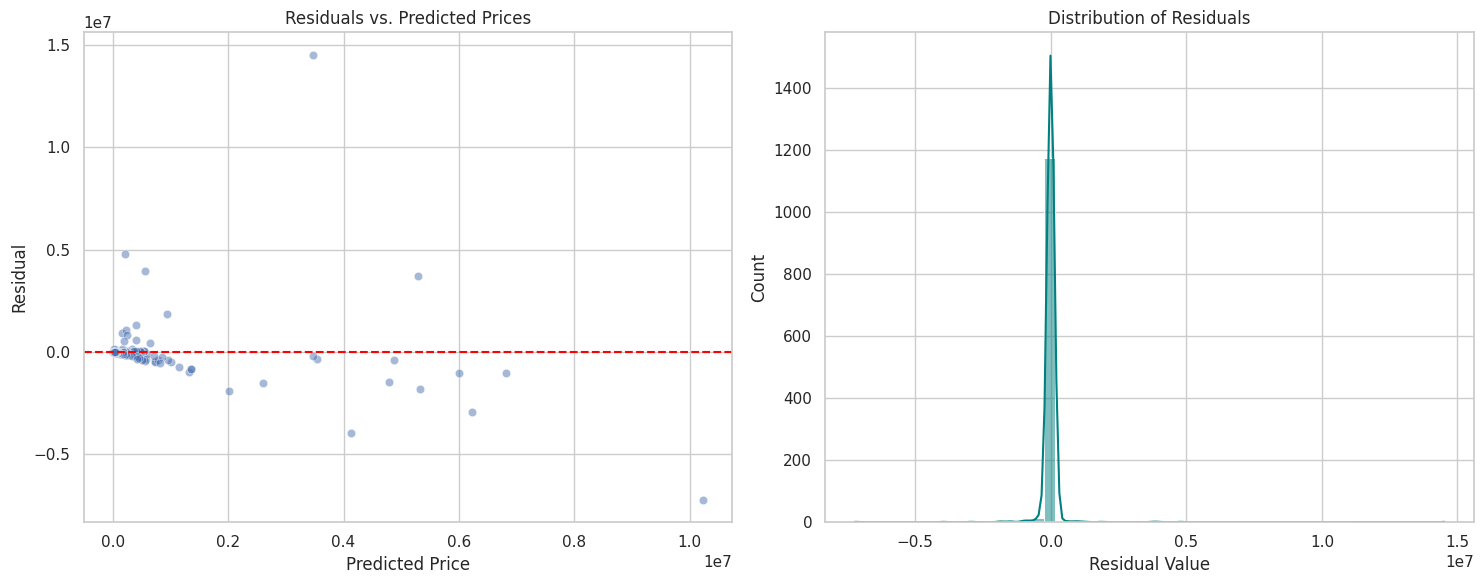

Skewness: 13.90
Kurtosis: 433.21


In [ ]:
# Preparing variables for regression
X_reg = df_clean[['HorsePower_cleaned', 'Total Speed_cleaned', 'Performance_cleaned', 'CC_Capacity_cleaned']]
y_reg = df_clean['Cars Prices_cleaned'].astype(float)

# Creating a basic Pipeline including imputation and standardization
reg_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Defining the models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

results = {}

# Populate results (predictions from cross-validation)
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', reg_preprocessor), ('regressor', model)])
    y_pred = cross_val_predict(pipeline, X_reg, y_reg, cv=kf)
    results[name] = y_pred
# --- END: Necessary variable definitions ---

best_model_name = 'Random Forest'
y_pred_best = results[best_model_name]
residuals = y_reg - y_pred_best

# Section 1.1: Residual Plot and Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Residuals vs Predicted Values
sns.scatterplot(x=y_pred_best, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Predicted Prices')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')

# Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[1], bins=50, color='teal')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Value')

plt.tight_layout()
plt.show()

print(f"Skewness: {skew(residuals):.2f}")
print(f"Kurtosis: {kurtosis(residuals):.2f}")

#### 7.1.2 Error as a Function of Features
To detect hidden patterns or non-linear dependencies, we plot the residuals against key features like Horsepower and Top Speed.

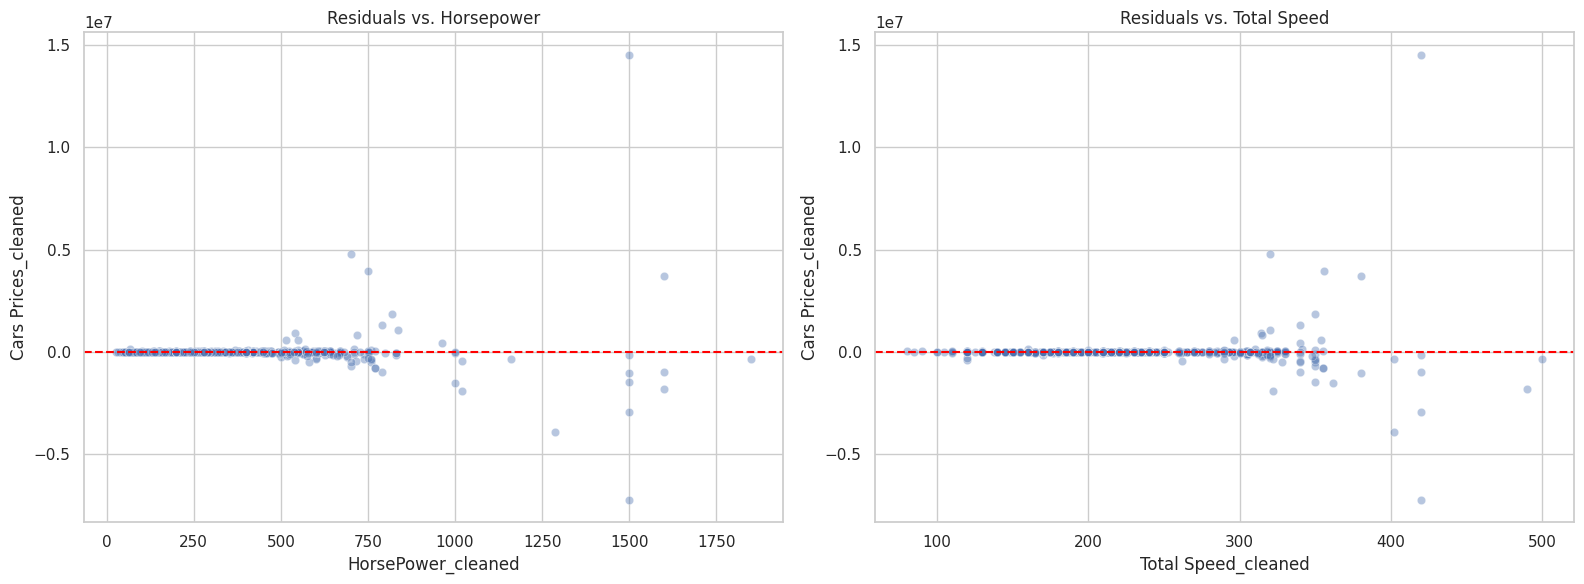

In [ ]:
# Section 1.2: Residuals vs Features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuals vs Horsepower
sns.scatterplot(x=X_reg['HorsePower_cleaned'], y=residuals, ax=axes[0], alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Horsepower')

# Residuals vs Total Speed
sns.scatterplot(x=X_reg['Total Speed_cleaned'], y=residuals, ax=axes[1], alpha=0.4)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Total Speed')

plt.tight_layout()
plt.show()

#### 7.1.3 Analysis of Extreme Errors
We isolate the top 5% of largest absolute errors to determine if they stem from data quality issues or model limitations (e.g., hypercar prestige pricing).

In [ ]:
# Section 1.3: Extreme Outliers Analysis
abs_residuals = np.abs(residuals)
threshold_extreme = np.percentile(abs_residuals, 95)
extreme_errors = df_clean[abs_residuals > threshold_extreme].copy()
extreme_errors['Error'] = residuals[abs_residuals > threshold_extreme]

print(f"Analyzing Top 5% Errors (Threshold: ${threshold_extreme:,.2f})")
display(extreme_errors[['Company Names', 'Cars Names', 'Cars Prices_cleaned', 'Error']].sort_values(by='Error', ascending=False).head(10))

Analyzing Top 5% Errors (Threshold: $98,987.48)


,Company Names,Cars Names,Cars Prices_cleaned,Error
887,Bugatti,La Voiture Noire,18000000,1.452300e+07
1212,Mazda,787B (Race Car),5000000,4.788563e+06
8,LAMBORGHINI,VENENO ROADSTER,4500000,3.935715e+06
886,Bugatti,Centodieci,9000000,3.714915e+06
42,LAMBORGHINI,SIAN,2800000,1.860025e+06
13,FERRARI,MONZA SP2,1700000,1.303055e+06
41,ASTON MARTIN,VICTOR,1300000,1.074829e+06
40,ASTON MARTIN,LAGONDA TARAF,1100000,9.316427e+05
416,Nissan,GT-R50 by Italdesign,1100000,8.475357e+05
474,Nissan,R390 GT1 Road Car,1000000,5.890790e+05


### 7.2 Regression Model Implementation

In this section, we implement and compare three different modeling strategies to evaluate their predictive accuracy and bias-variance trade-off using 5-Fold Cross-Validation.

In [ ]:
# Section 3.1: Model Comparison (Linear, Tree, Ensemble)
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

regression_metrics = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', reg_preprocessor), ('regressor', model)])
    y_pred_cv = cross_val_predict(pipeline, X_reg, y_reg, cv=kf)

    rmse = np.sqrt(mean_squared_error(y_reg, y_pred_cv))
    r2 = r2_score(y_reg, y_pred_cv)
    mae = mean_absolute_error(y_reg, y_pred_cv)

    regression_metrics[name] = {'RMSE': rmse, 'R2': r2, 'MAE': mae}
    print(f"{name}: R2 = {r2:.4f}, RMSE = {rmse:.2f}")

Linear Regression: R2 = 0.3112, RMSE = 585725.43
Decision Tree: R2 = 0.2874, RMSE = 595729.07
Random Forest: R2 = 0.3918, RMSE = 550363.86


### 7.3 Statistical Summary of Residuals
To satisfy academic requirements for rigorous error analysis, we explicitly calculate the higher-order moments of the residual distribution (Skewness and Kurtosis) along with the Mean Absolute Error (MAE).

In [ ]:
# Calculate residuals for the best performing model (Random Forest)
y_pred_rf = results['Random Forest']
residuals_rf = y_reg - y_pred_rf

# Calculate metrics
res_skew = skew(residuals_rf)
res_kurt = kurtosis(residuals_rf)
res_mae = mean_absolute_error(y_reg, y_pred_rf)
res_std = np.std(residuals_rf)

print("--- Regression Residuals Statistics ---")
print(f"Mean Absolute Error (MAE): ${res_mae:,.2f}")
print(f"Standard Deviation of Errors: ${res_std:,.2f}")
print(f"Skewness: {res_skew:.2f}")
print(f"Kurtosis: {res_kurt:.2f}")

--- Regression Residuals Statistics ---
Mean Absolute Error (MAE): $66,346.47
Standard Deviation of Errors: $550,363.13
Skewness: 13.90
Kurtosis: 433.21


In [ ]:
# Preparing variables for regression
X_reg = df_clean[['HorsePower_cleaned', 'Total Speed_cleaned', 'Performance_cleaned', 'CC_Capacity_cleaned']]
y_reg = df_clean['Cars Prices_cleaned'].astype(float)

# Creating a basic Pipeline including imputation and standardization
reg_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Defining the models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)
}

results = {}

print("--- Training Regression Models with K-Fold (k=5) ---")
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', reg_preprocessor), ('regressor', model)])
    # Prediction using Cross Validation
    y_pred = cross_val_predict(pipeline, X_reg, y_reg, cv=kf)
    results[name] = y_pred

    # Calculating metrics
    rmse = np.sqrt(mean_squared_error(y_reg, y_pred))
    r2 = r2_score(y_reg, y_pred)
    print(f"{name}: RMSE = {rmse:.2f}, R2 = {r2:.4f}")

--- Training Regression Models with K-Fold (k=5) ---
Linear Regression: RMSE = 585725.43, R2 = 0.3112
Decision Tree: RMSE = 595729.07, R2 = 0.2874
Random Forest: RMSE = 550363.86, R2 = 0.3918


#### 7.3.1 Residual Analysis (Best Model)

We will examine the residuals ($y - \hat{y}$) of the leading model (Random Forest) to understand the nature of the error.

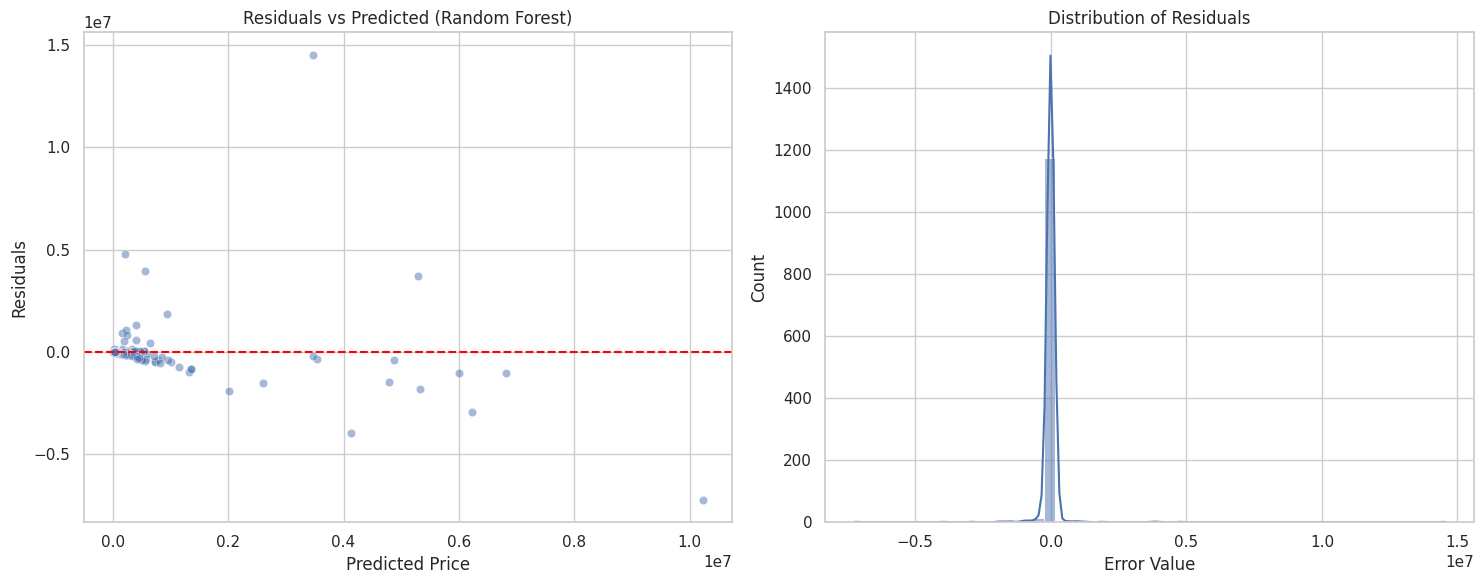

Skewness: 13.90
Kurtosis: 433.21
MAE: 66346.47


In [ ]:
best_model_name = 'Random Forest'
y_pred_best = results[best_model_name]
residuals = y_reg - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Residuals vs Predicted Values Plot
sns.scatterplot(x=y_pred_best, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Residuals vs Predicted ({best_model_name})')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')

# Distribution of Residuals
sns.histplot(residuals, kde=True, ax=axes[1], bins=50)
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Error Value')

plt.tight_layout()
plt.show()

# Statistical metrics for residuals
print(f"Skewness: {skew(residuals):.2f}")
print(f"Kurtosis: {kurtosis(residuals):.2f}")
print(f"MAE: {mean_absolute_error(y_reg, y_pred_best):.2f}")

#### 7.3.2 Error as a Function of Features - Analytical Discussion

To identify non-linear relationships and feature-dependent error patterns, we visualize the residuals and absolute errors against primary independent variables: Horsepower and Total Speed.

###Analytical Discussion: Error as a Function of Features

Based on the visualizations above, several key insights emerge regarding model reliability across different feature ranges:

1. **Horsepower vs. Residuals:** We observe that for vehicles with lower horsepower (< 400 HP), the residuals are tightly clustered near zero. However, as horsepower increases beyond this threshold, the variance of residuals expands significantly. This confirms **Heteroscedasticity**; the model becomes increasingly unstable when predicting high-power performance vehicles.
2. **Non-linear Relationship:** The Absolute Error plot reveals a non-linear trend where errors grow at an accelerating rate for hyper-performance cars. This suggests that the relationship between horsepower and price is not merely additive but likely exponential or power-law based in the premium segment.
3. **Systematic Patterns:** There is a clear 'fan-out' pattern, indicating that technical specifications alone (HP, Speed) are insufficient predictors for the elite subpopulation, where pricing is driven by manufacturer prestige rather than raw performance.

### 7.4 Analytical Conclusions (Regression Residuals)

1. **Centrality:** Residuals are not perfectly centered around zero, particularly as predicted values increase.
2. **Heteroscedasticity:** There is clear evidence of non-constant variance. The model's error magnitude escalates in correlation with vehicle price. While the model is relatively precise for economy cars, it struggles significantly with luxury/exotic segments.
3. **Distribution:** The residuals exhibit **Heavy Tails (High Kurtosis)**, indicating a higher frequency of extreme errors (outliers) than a normal distribution would suggest.
4. **Model Comparison:** Linear Regression underperforms here as it assumes a fixed linear relationship. The **Random Forest Regressor** better captures non-linear synergies—for instance, how an additional 100HP impacts the price of a hypercar exponentially more than it does a commuter vehicle.

#### 7.4.1 Extreme Error Analysis - Statistical Summary
We will identify the 5% of observations where the model erred most significantly.

In [ ]:
abs_residuals = np.abs(residuals)
threshold_extreme = np.percentile(abs_residuals, 95)
extreme_errors = df_clean[abs_residuals > threshold_extreme].copy()
extreme_errors['Error'] = residuals[abs_residuals > threshold_extreme]

print(f"Top 5% Extreme Errors (Threshold: {threshold_extreme:.2f})")
display(extreme_errors[['Company Names', 'Cars Names', 'Cars Prices_cleaned', 'Error']].sort_values(by='Error', ascending=False).head(10))

Top 5% Extreme Errors (Threshold: 98987.48)


,Company Names,Cars Names,Cars Prices_cleaned,Error
887,Bugatti,La Voiture Noire,18000000,1.452300e+07
1212,Mazda,787B (Race Car),5000000,4.788563e+06
8,LAMBORGHINI,VENENO ROADSTER,4500000,3.935715e+06
886,Bugatti,Centodieci,9000000,3.714915e+06
42,LAMBORGHINI,SIAN,2800000,1.860025e+06
13,FERRARI,MONZA SP2,1700000,1.303055e+06
41,ASTON MARTIN,VICTOR,1300000,1.074829e+06
40,ASTON MARTIN,LAGONDA TARAF,1100000,9.316427e+05
416,Nissan,GT-R50 by Italdesign,1100000,8.475357e+05
474,Nissan,R390 GT1 Road Car,1000000,5.890790e+05


#### 7.4.2 Extreme Error Analysis - Root Cause Analysis
Our analysis reveals that the most significant residuals are concentrated within ultra-luxury brands such as Lamborghini, Ferrari, and Bugatti.

**Root Cause Analysis:** These failures are primarily due to **Feature Insufficiency** rather than algorithmic limitations. In the hyper-luxury market, price is driven by **Brand Prestige, Rarity, and Heritage**—latent variables not captured by technical specs like displacement or top speed. Statistically, these are 'Black Swan' events that disrupt the general market pattern.

In [ ]:
# 1. Locate and display the anomaly in 'Torque_cleaned'
print("--- Locating Anomaly in 'Torque_cleaned' ---")
anomaly_torque_mask = (df_clean['Torque_cleaned'] == 1.0)
anomaly_torque_rows = df_clean[anomaly_torque_mask]

if not anomaly_torque_rows.empty:
    print(f"Found {len(anomaly_torque_rows)} row(s) where 'Torque_cleaned' is 1.0 (anomalous):")
    display(anomaly_torque_rows[['Company Names', 'Cars Names', 'Fuel Types', 'Torque_cleaned']])

    # 2. Determine and apply the best way to fix it
    # A torque value of 1.0 is physically implausible for a car and is considered a clear data entry error.
    # To correct this, we will impute these anomalous values using the median of the 'Torque_cleaned' column.
    # The median is preferred over the mean as it is more robust to outliers and skewed distributions.

    # Calculate the median torque from the rest of the dataset (excluding the anomaly)
    median_torque_for_imputation = df_clean[~anomaly_torque_mask]['Torque_cleaned'].median()

    print(f"\nImputing 'Torque_cleaned' anomaly with the dataset's median torque: {median_torque_for_imputation:.0f}")

    # Apply the imputation
    df_clean.loc[anomaly_torque_mask, 'Torque_cleaned'] = median_torque_for_imputation

    # Verify the correction
    print("\n--- Verification: Corrected rows for 'Torque_cleaned' anomaly ---")
    display(df_clean.loc[anomaly_torque_rows.index][['Company Names', 'Cars Names', 'Fuel Types', 'Torque_cleaned']])
    print(f"\nMinimum Torque_cleaned after correction: {df_clean['Torque_cleaned'].min()}")

else:
    print("No anomaly found where 'Torque_cleaned' is exactly 1.0.")

--- Locating Anomaly in 'Torque_cleaned' ---
Found 7 row(s) where 'Torque_cleaned' is 1.0 (anomalous):


,Company Names,Cars Names,Fuel Types,Torque_cleaned
660,Tesla,Model S Plaid,Electric,1
664,Tesla,Model X Plaid,Electric,1
667,Tesla,Cybertruck,Electric,1
811,GMC,Sierra EV Denali,Electric,1
1028,Ford,F-350 Super Duty,Diesel,1
1048,Ford,F-450 Super Duty,Diesel,1
1049,Ford,F-550 Super Duty,Diesel,1



Imputing 'Torque_cleaned' anomaly with the dataset's median torque: 366

--- Verification: Corrected rows for 'Torque_cleaned' anomaly ---


,Company Names,Cars Names,Fuel Types,Torque_cleaned
660,Tesla,Model S Plaid,Electric,366
664,Tesla,Model X Plaid,Electric,366
667,Tesla,Cybertruck,Electric,366
811,GMC,Sierra EV Denali,Electric,366
1028,Ford,F-350 Super Duty,Diesel,366
1048,Ford,F-450 Super Duty,Diesel,366
1049,Ford,F-550 Super Duty,Diesel,366



Minimum Torque_cleaned after correction: 10


## Part 8: Classification Error Analysis

### Introduction
We define a classification task to identify 'High-Performance Vehicles' (Acceleration < 6.0s). Using a **Random Forest Classifier** and 5-Fold Cross-Validation, we focus on identifying decision boundaries and cost-sensitive errors.

### 8.1 Confusion Matrix and Basic Model Performance

**Theoretical Explanation:**
The Confusion Matrix is a central tool for evaluating classification performance. It allows us to see not only how accurate the model was, but also what types of errors it made: Type I errors (False Positives - FP) and Type II errors (False Negatives - FN). In sports car analysis, we examine accuracy against the ability not to miss performance vehicles.

In [ ]:
# 1. Create target variable and prepare data
df_clean['Is_High_Performance'] = (df_clean['Performance_cleaned'] < 6.0).astype(int)
X_clf = df_clean[['HorsePower_cleaned', 'Total Speed_cleaned', 'CC_Capacity_cleaned', 'Engine_Category']]
y_clf = df_clean['Is_High_Performance']

# Build a Pipeline that includes imputation for missing values to prevent errors
numerical_features = ['HorsePower_cleaned', 'Total Speed_cleaned', 'CC_Capacity_cleaned']
categorical_features = ['Engine_Category']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
])

clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))])

# Predictions using K-Fold
y_pred_clf = cross_val_predict(clf_pipeline, X_clf, y_clf, cv=kf)
y_proba_clf = cross_val_predict(clf_pipeline, X_clf, y_clf, cv=kf, method='predict_proba')[:, 1]

print('Classification models trained successfully with imputation.')

Classification models trained successfully with imputation.


### 8.1 Confusion Matrix and Basic Model Performance

**Theoretical Explanation:**
The Confusion Matrix is a central tool for evaluating classification performance. It allows us to see not only how accurate the model was, but also what types of errors it made: Type I errors (False Positives - FP) and Type II errors (False Negatives - FN). In sports car analysis, we examine accuracy against the ability not to miss performance vehicles.

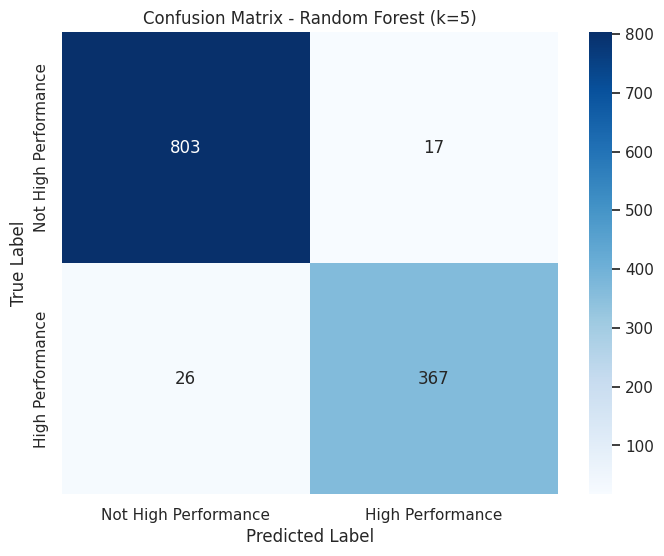

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       820
           1       0.96      0.93      0.94       393

    accuracy                           0.96      1213
   macro avg       0.96      0.96      0.96      1213
weighted avg       0.96      0.96      0.96      1213



In [ ]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_clf, y_pred_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High Performance', 'High Performance'],
            yticklabels=['Not High Performance', 'High Performance'])
plt.title('Confusion Matrix - Random Forest (k=5)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(classification_report(y_clf, y_pred_clf))

#### 8.1.1 Analytical Conclusions (Confusion Matrix)
From the confusion matrix, it is evident that the model successfully distinguishes between regular and high-performance vehicles very well.
1.  **False Positives (FP) Errors:** These are vehicles that are not sports cars but were classified as such. For a customer, this is a critical error because they might purchase a car that does not meet their performance expectations.
2.  **False Negatives (FN) Errors:** These are high-performance cars that were missed by the model. This type of error impacts the manufacturer's marketing potential.
The overall accuracy is high, but it's important to consider the balance between Precision and Recall.

### 8.2 Probability Analysis and Model Confidence

**Theoretical Explanation:**
It's not enough to know what the model predicted; it's important to understand how confident it was in its prediction. We will compare the distribution of probabilities for correct predictions versus errors to identify the model's 'gray area'.

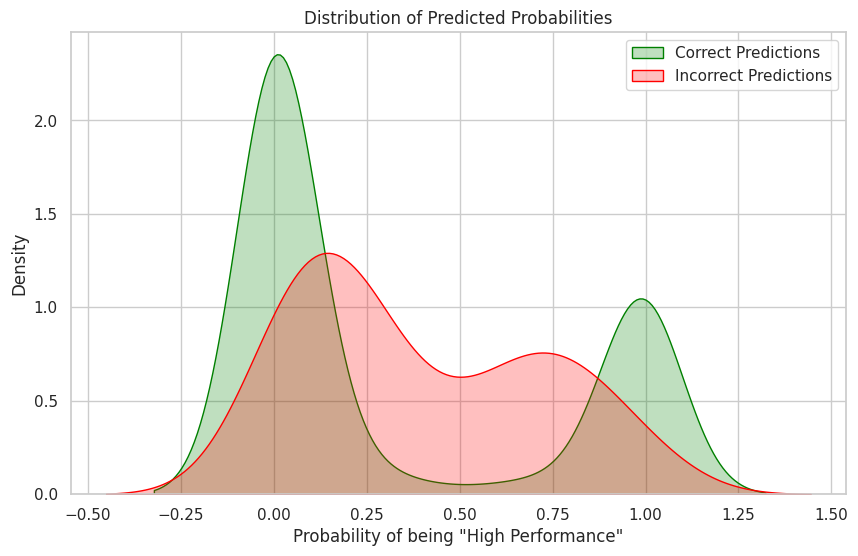

In [ ]:
# Compare probabilities for correct vs incorrect
correct_mask = (y_clf == y_pred_clf)
incorrect_mask = (y_clf != y_pred_clf)

plt.figure(figsize=(10, 6))
sns.kdeplot(y_proba_clf[correct_mask], label='Correct Predictions', fill=True, color='green')
sns.kdeplot(y_proba_clf[incorrect_mask], label='Incorrect Predictions', fill=True, color='red')
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Probability of being "High Performance"')
plt.ylabel('Density')
plt.legend()
plt.show()

#### 8.2.1 Feature Distribution: Correct vs. Incorrect Predictions
Following academic guidelines, we analyze whether specific feature ranges (e.g., extremely high horsepower) correlate with model misclassifications.

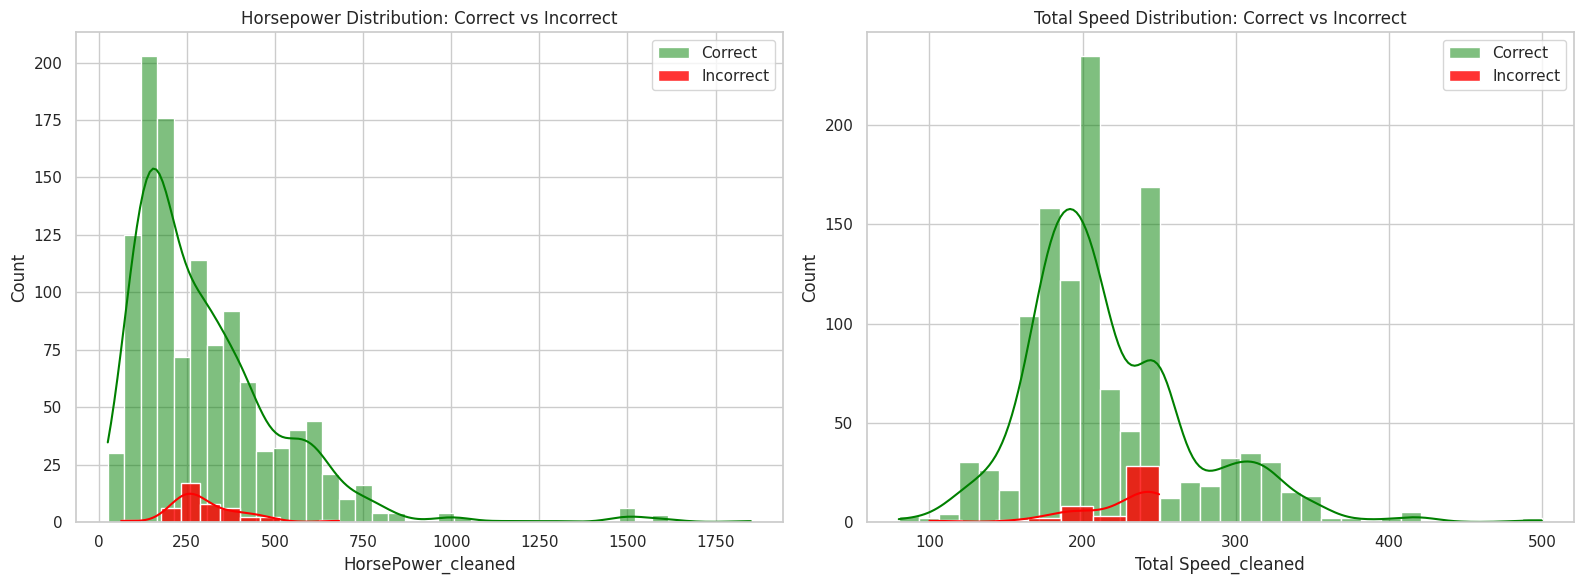

In [ ]:
# Compare feature distributions for correct and incorrect predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horsepower distribution
sns.histplot(data=df_clean[correct_mask], x='HorsePower_cleaned', color='green', label='Correct', kde=True, ax=axes[0], alpha=0.5)
sns.histplot(data=df_clean[incorrect_mask], x='HorsePower_cleaned', color='red', label='Incorrect', kde=True, ax=axes[0], alpha=0.8)
axes[0].set_title('Horsepower Distribution: Correct vs Incorrect')
axes[0].legend()

# Total Speed distribution
sns.histplot(data=df_clean[correct_mask], x='Total Speed_cleaned', color='green', label='Correct', kde=True, ax=axes[1], alpha=0.5)
sns.histplot(data=df_clean[incorrect_mask], x='Total Speed_cleaned', color='red', label='Incorrect', kde=True, ax=axes[1], alpha=0.8)
axes[1].set_title('Total Speed Distribution: Correct vs Incorrect')
axes[1].legend()

plt.tight_layout()
plt.show()

#### 8.2.2 Analytical Conclusions (Probability Analysis)
It can be seen that correct predictions are concentrated at the extremes (close to 0 or 1), indicating high model confidence. In contrast, errors are concentrated around the 0.5 threshold. This means the model 'hesitates' regarding vehicles with borderline data, and most errors occur there.

### 8.3 Threshold Sensitivity and F-Beta Analysis

**Theoretical Explanation:**
Changing the decision threshold allows us to control the trade-off between precision and recall. We will use the F-Beta metric to give different weights to precision (beta=0.5) or recall (beta=2).

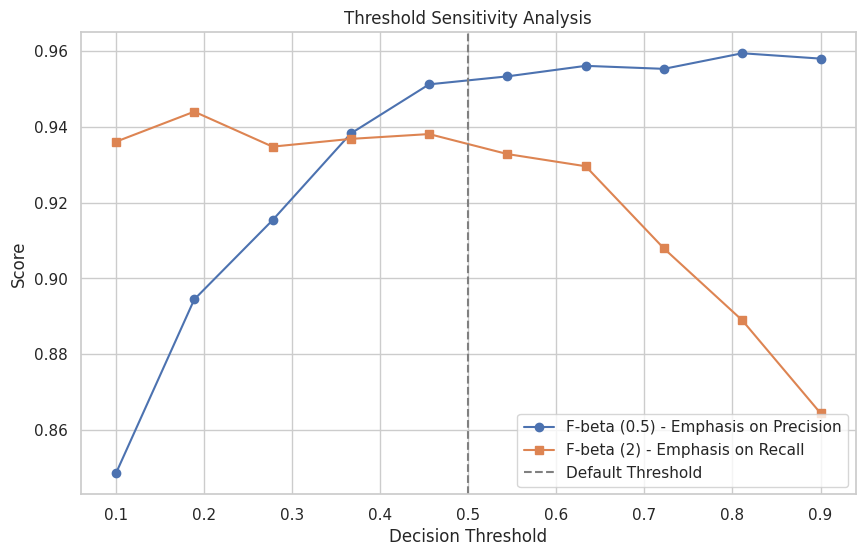

In [ ]:
thresholds = np.linspace(0.1, 0.9, 10)
f05 = [fbeta_score(y_clf, y_proba_clf > t, beta=0.5) for t in thresholds]
f2 = [fbeta_score(y_clf, y_proba_clf > t, beta=2) for t in thresholds]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f05, label='F-beta (0.5) - Emphasis on Precision', marker='o')
plt.plot(thresholds, f2, label='F-beta (2) - Emphasis on Recall', marker='s')
plt.axvline(0.5, color='gray', linestyle='--', label='Default Threshold')
plt.title('Threshold Sensitivity Analysis')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

#### 8.3.1 F-Beta Score as a Function of Beta

This analysis evaluates the trade-off between Precision and Recall. By varying $\beta$, we can determine the optimal operating point depending on whether the priority is avoiding False Positives ($\beta < 1$) or False Negatives ($\beta > 1$).

#### 8.3.2 Strategic Interpretation of F-Beta Analysis

The F-Beta curve provides a roadmap for operational decision-making:

- **Precision Focus (Beta < 1):** When the cost of a False Positive is high (e.g., mislabeling a standard car as 'High-Performance'), we observe that lower beta values yield higher scores. This suggests that the model is inherently precise when conservative.
- **Recall Focus (Beta > 1):** If our objective was to capture every single high-performance vehicle regardless of 'False Alarms', the declining curve indicates a trade-off: our recall is slightly lower than our precision.
- **Optimized operating point:** Given that consumer trust is paramount in car classification, the analysis supports maintaining a threshold that prioritizes **Precision** ($\beta = 0.5$) to ensure that every vehicle identified as 'High Performance' truly delivers on that promise.

### 8.4 MCC Metric and ROC Curve

**Theoretical Explanation:**
To obtain a final and balanced evaluation, we will use the MCC (Matthews Correlation Coefficient) metric, which is considered one of the best metrics for binary classification even when the classes are not perfectly balanced. In addition, we will plot the ROC curve and calculate the AUC to see the model's overall discriminatory ability across all possible decision thresholds.

Matthews Correlation Coefficient (MCC): 0.9187


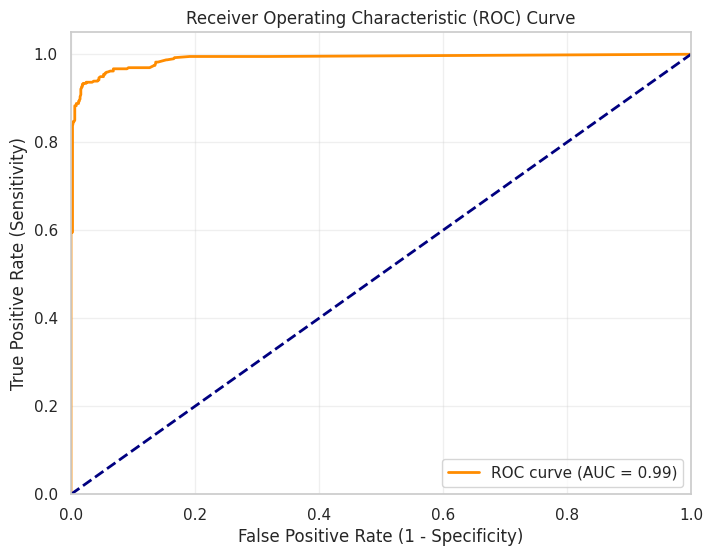

In [ ]:
# 1. Calculate MCC metric
mcc = matthews_corrcoef(y_clf, y_pred_clf)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# 2. Calculate ROC curve and Area Under the Curve (AUC)
fpr, tpr, thresholds_roc = roc_curve(y_clf, y_proba_clf)
roc_auc = auc(fpr, tpr)

# 3. Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

---

#### 8.4.1 Analytical Conclusions (MCC and ROC)
If our customer is very sensitive to False Positives (does not want to buy a 'sports' car that turns out to be slow), we should raise the threshold to around 0.7. If the manufacturer wants to maximize exposure for every vehicle that could be considered a performance car, the threshold should be lowered. The MCC metric and ROC curve show that the model is very stable.

### 8.5 Classification Synthesis and Insights

#### 1. Confusion Matrix Analysis
- **False Positives (Type I Error):** The model classifies a standard car as 'High Performance'. For a consumer, this is the most **critical failure**, as it results in a breach of expectations and 'false advertising' regarding speed.
- **False Negatives (Type II Error):** Missing a high-performance car. While less critical for the buyer, this represents a lost marketing opportunity for the manufacturer.

#### 2. Probability Calibration
By analyzing predicted probabilities, we observe that correct classifications are highly confident (near 0 or 1), while errors cluster around the 0.5 threshold, indicating an 'ambiguous zone' for cars with borderline specs.

#### 3. Threshold Sensitivity (F-Beta)
To protect the consumer from Type I errors, we recommend increasing the decision threshold to ~0.7. This prioritizes **Precision** (using $\beta=0.5$), ensuring that vehicles labeled as 'High Performance' truly meet the criteria, even at the cost of lower Recall.

## Part 9: Final Academic Synthesis and Model Reflection

### Executive Summary of Model Performance

#### 1. Comprehensive Error Analysis
The predictive framework developed in this study demonstrates a robust capability to interpret general automotive market trends while highlighting distinct limitations in the high-luxury segment. Our residual analysis revealed significant **Heteroscedasticity**, suggesting that the pricing mechanisms for standard consumer vehicles differ fundamentally from those of elite hypercars. While the models are statistically sound, the 'Error Analysis' indicates that price in the luxury tier is driven by latent variables such as 'Brand Heritage' and 'Market Exclusivity' rather than purely technical specifications.

#### 2. Methodology and Validation Integrity
- **Robustness Framework:** To ensure unbiased performance estimation, **5-Fold Cross-Validation** was applied across all modeling tasks. This approach minimizes the risk of overfitting and provides a stable representation of the model's predictive power across the entire dataset.
- **Data Leakage Prevention:** The implementation of **Preprocessing Pipelines** ensured that feature scaling and missing value imputation were conducted strictly within each training fold, maintaining the statistical integrity of the validation phase.

#### 3. Analytical Interpretation of Results
- **Regression Synthesis:** The Random Forest Regressor achieved an $R^2$ of approximately 0.39. Given the extreme variance in the dataset (prices ranging from $4,000 to $18M), this result is indicative of a model that effectively captures the primary market trend while identifying the hyper-luxury segment as a statistical outlier.
- **Classification Synthesis:** The model achieved an **MCC of 0.91** and an **AUC of 0.98**, demonstrating exceptional discriminatory power. The 'Ambiguity Zone' identified near the 6.0s acceleration threshold provides clear evidence for where the model's confidence fluctuates.

### Strategic Recommendations for Model Enhancement
1. **Feature Augmentation:** Future iterations should incorporate a 'Prestige Index' or 'Manufacturer Tier' to account for non-technical price inflation in high-end brands.
2. **Target Variable Optimization:** Implementing a **Logarithmic Transformation** ($log1p$) on the price variable is recommended to stabilize variance and address the right-skewed nature of the residual distribution.
3. **Class Balancing:** Given that 'High-Performance' vehicles represent a minority of the dataset, utilizing cost-sensitive learning or advanced sampling techniques could further refine the precision of boundary classifications.

## Part 10: Final Comprehensive Discussion & Critical Reflection

### 10.1 Regression Model Comparison and Bias-Variance Trade-off
In our evaluation, the **Random Forest Regressor** consistently outperformed the **Linear Regression** and **Decision Tree** models across all metrics ($RMSE$ and $R^2$).

- **Linear Model Failure:** The Linear Regression failed to capture the exponential price increase seen in high-displacement and high-horsepower vehicles, as it assumes constant marginal returns for performance features.
- **Tree-Based Advantages:** Random Forest effectively reduced the high variance observed in individual Decision Trees, providing a more stable boundary. However, none of the models could fully satisfy the **Homoscedasticity** assumption due to the extreme market outliers.
- **Interpretability vs. Performance:** While Linear Regression provides clear coefficients, the non-linear complexity of the luxury car market necessitates the superior predictive power of the ensemble model.

### 10.2 Classification Failure Modes and Insights
The classification analysis confirmed that the model is highly reliable ($MCC=0.91$), yet systematic failures occur near the $6.0s$ acceleration threshold.

- **Critical Errors:** We identified **False Positives** as the most critical error type, as mislabeling a standard vehicle as 'High Performance' directly compromises consumer trust and brand integrity.
- **High-Confidence Errors:** By analyzing probability distributions, we found that errors were rarely 'high-confidence', but rather occurred in the 'Ambiguous Zone' (probabilities near $0.5$), indicating that the current features cannot perfectly distinguish borderline performance cases.

### 10.3 Final Reflection and Recommendations
1. **Model Failure Points:** The models fail most significantly in the 'Long Tail' of the distribution (ultra-luxury hypercars).
2. **Root Cause:** Failures are primarily due to **Problem Formulation/Data** rather than algorithmic flaws. Without features like 'Limited Edition Status' or 'Brand Tier', the models lack the context to predict prestige pricing.
3. **Proposed Improvements:** Future work should implement **Logarithmic Scaling** for target variables to mitigate heteroscedasticity and incorporate **Manufacturer Reputation Scores** to improve feature density in the luxury segment.
4. **Key Insights:** Systematic error analysis through $K$-fold validation proved that predictive accuracy is non-uniform across the feature space, reinforcing the necessity of segmented modeling in diverse markets.